# GridForge 14-Bus Unit-Commitment Walkthrough

This notebook walks through the prepared 14-bus example interactively. It shows how the YAML configuration becomes an Excel workbook, how bus-level CSV data is loaded, and how the resulting `Grid` and `Data` objects can be inspected before building an optimization model.

The notebook avoids solving the mixed-integer unit-commitment problem by default, so it can be used without a commercial solver.

## 1. Setup

Run this notebook from the repository root or from `examples/14bus_uc/`. The cell below finds the repository root and imports GridForge from the local checkout.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if HERE.name == "14bus_uc":
    EXAMPLE_DIR = HERE
    REPO = HERE.parents[1]
else:
    REPO = HERE
    EXAMPLE_DIR = REPO / "examples" / "14bus_uc"

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

CONFIG_YAML = EXAMPLE_DIR / "14bus_config.yaml"
CONFIG_XLSX = EXAMPLE_DIR / "14bus_config.xlsx"
ASSIGNMENT_YAML = EXAMPLE_DIR / "14bus_data_assignment.yaml"
DATA_DIR = EXAMPLE_DIR / "14bus_data"

print("repo:", REPO)
print("example:", EXAMPLE_DIR)
print("config YAML exists:", CONFIG_YAML.exists())
print("data assignment YAML exists:", ASSIGNMENT_YAML.exists())

repo: /home/wx/my_project/gridforge
example: /home/wx/my_project/gridforge/examples/14bus_uc
config YAML exists: True
data assignment YAML exists: True


## 2. Build The Static Grid Workbook

The YAML file is the source of truth for the static grid construction. It starts from a PYPOWER case and adds/modifies GridForge sheets such as `load`, `solar`, and `wind`.

In [2]:
from gridforge.construct import construct_grid_config

construct_grid_config(
    config_path =str(CONFIG_YAML),
    output_path = str(CONFIG_XLSX),
    random_seed=404,
)

print("wrote:", CONFIG_XLSX)



Constructing the grid configuration...


Reading config from /home/wx/my_project/gridforge/examples/14bus_uc/14bus_config.yaml
Applied rescale 'load_to_active_supply_ratio': scaled by 2.328185 on load.PMAX (target=603.000000, current=259.000000).
Saved the grid configuration excel file to /home/wx/my_project/gridforge/examples/14bus_uc/14bus_config.xlsx
wrote: /home/wx/my_project/gridforge/examples/14bus_uc/14bus_config.xlsx


## 3. Inspect Workbook Sheets

The generated workbook contains core sheets (`bus`, `gen`, `branch`) plus custom bus-attached sheets such as `load`, `solar`, and `wind`.

In [3]:
import pandas as pd

sheets = pd.read_excel(CONFIG_XLSX, sheet_name=None, engine="openpyxl")
print("sheets:", list(sheets))

summary = pd.DataFrame(
    {
        "sheet": list(sheets),
        "rows": [len(df) for df in sheets.values()],
        "columns": [len(df.columns) for df in sheets.values()],
    }
)
summary

sheets: ['bus', 'gen', 'branch', 'solar', 'wind', 'load', '__metadata__']


,sheet,rows,columns
0,bus,14,13
1,gen,2,28
2,branch,20,13
3,solar,2,4
4,wind,1,4
5,load,11,4
6,__metadata__,4,2


In [4]:
# Change this name to inspect another workbook sheet.
sheet_name = "solar"
sheets[sheet_name].head()

,BUS_IDX,PMAX,CURTAIL_COST,STATUS
0,2,140,64.051802,1
1,8,150,56.417072,1


## 4. Visualize The Grid Topology

The topology is built from the generated workbook, so it reflects any bus, branch, or custom asset edits from the YAML.

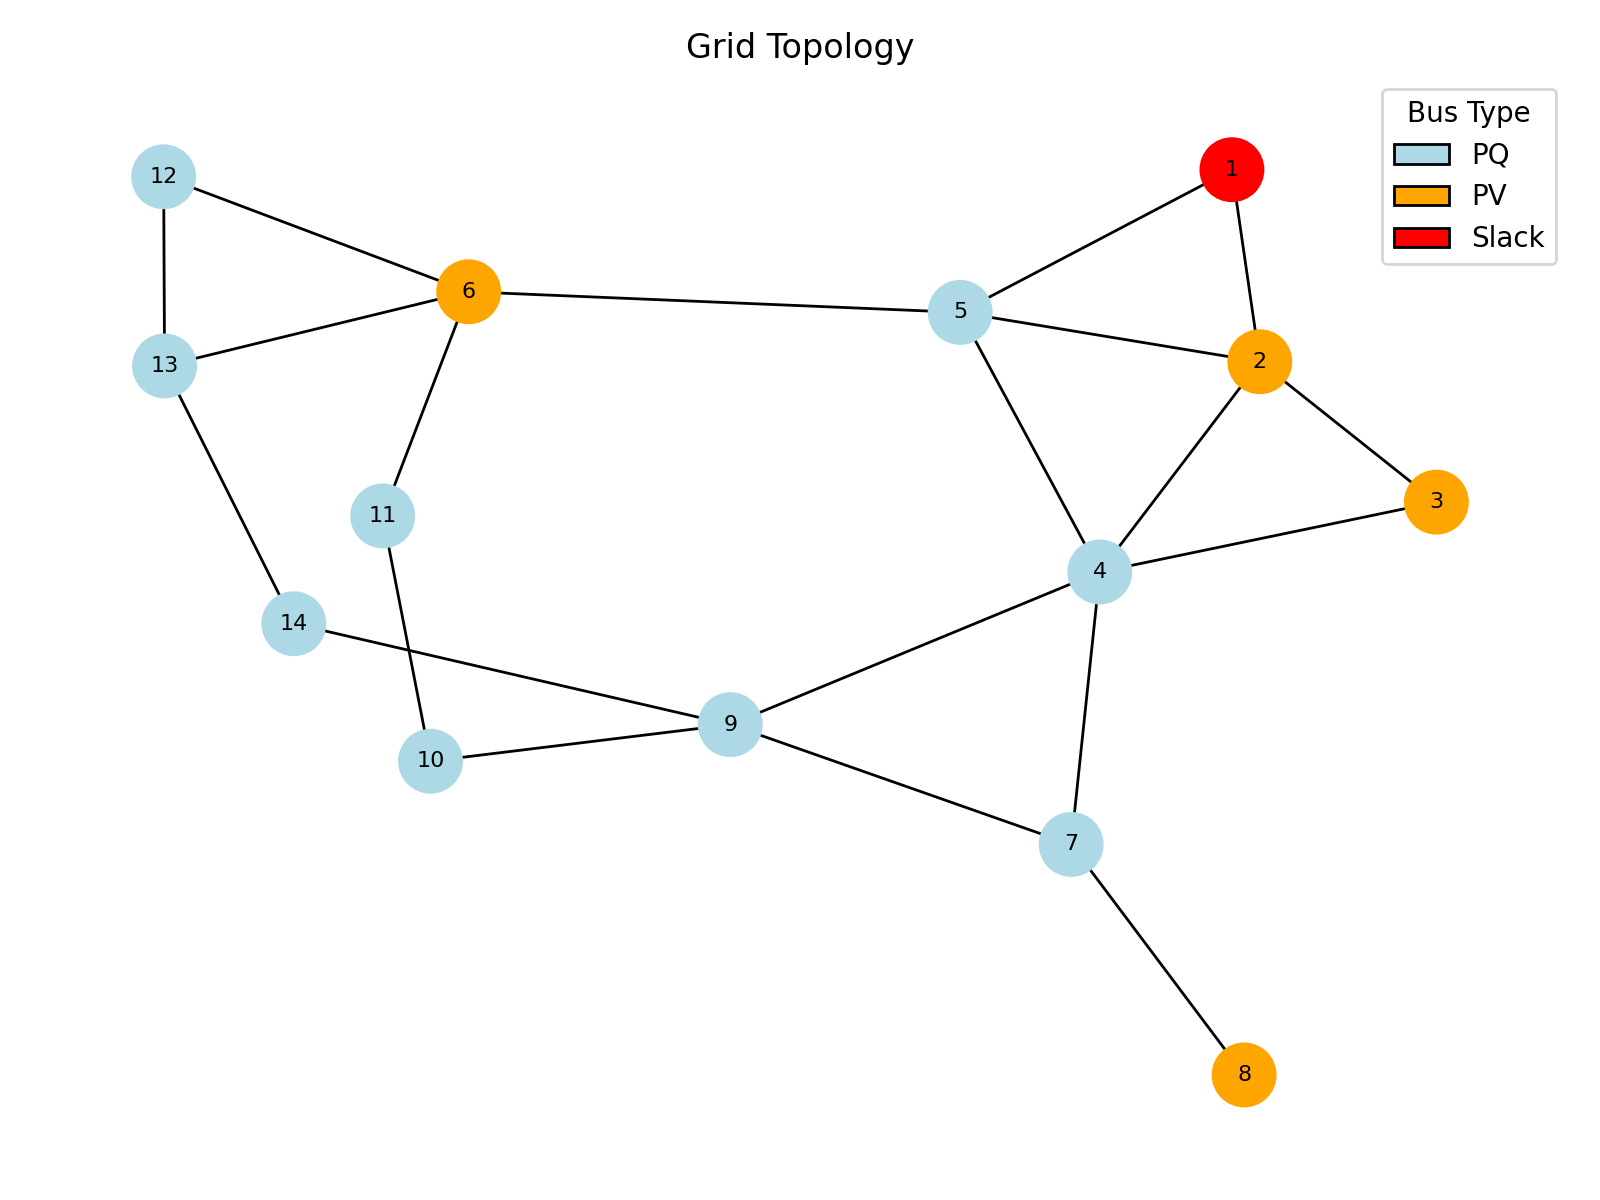

interactive HTML: /home/wx/my_project/gridforge/examples/14bus_uc/14bus_topology.html


In [5]:
from IPython.display import Image, display
from gridforge.plot import draw_grid_topology, draw_grid_topology_interactive

topology_png = EXAMPLE_DIR / "14bus_topology.png"
topology_html = EXAMPLE_DIR / "14bus_topology.html"

draw_grid_topology(str(CONFIG_XLSX), output_path=str(topology_png))
draw_grid_topology_interactive(str(CONFIG_XLSX), output_path=str(topology_html))

display(Image(filename=str(topology_png)))
print("interactive HTML:", topology_html)

## 5. Materialize Bus-Level Time-Series Data

The assignment YAML maps generated GridForge `BUS_IDX` values to source CSV profiles. If `examples/14bus_uc/14bus_data/` already exists, this step can simply refresh it. If the source pool `data/bus_data/` is missing, run the TX-123BT preprocessing workflow first. See [tx123bt.md](docs/tx123bt.md) for details.

In [6]:
from gridforge.data import (
    load_bus_data_assignment,         
    materialize_bus_data_assignment,  # Generate bus-level compatible CSV files
    save_bus_data_assignment,         # Save the assignment YAML
    suggest_bus_data_assignment,      # Suggest bus-data assignment
)

assignment_template = load_bus_data_assignment(str(ASSIGNMENT_YAML))
source_data_dir = REPO / "data/bus_data"

resolved_assignment_path = EXAMPLE_DIR / "14bus_data_assignment_resolved.yaml"

if source_data_dir.exists():
    assignment = suggest_bus_data_assignment(
        grid_xlsx_path=str(CONFIG_XLSX),
        source_data_dir=str(source_data_dir),
        signals=assignment_template["signals"],
        output_data_dir=str(DATA_DIR),
        random_seed=404,
    )
    save_bus_data_assignment(assignment, str(resolved_assignment_path))
    materialize_bus_data_assignment(
        grid_xlsx_path=str(CONFIG_XLSX),
        assignment=assignment,
        verbose=0,
    )
    print("saved resolved assignment:", resolved_assignment_path)
    print("materialized bus data under:", DATA_DIR)
elif DATA_DIR.exists() and list(DATA_DIR.glob("bus_*.csv")):
    print("source data pool not found:", source_data_dir)
    print("using existing prepared bus data under:", DATA_DIR)
else:
    raise FileNotFoundError(
        f"Missing source data pool: {source_data_dir}. "
        "Run `bash scripts/generate_tx123bt_bus_data.sh` from the repo root first."
    )

sorted(p.name for p in DATA_DIR.glob("bus_*.csv"))[:10]


saved resolved assignment: /home/wx/my_project/gridforge/examples/14bus_uc/14bus_data_assignment_resolved.yaml
materialized bus data under: /home/wx/my_project/gridforge/examples/14bus_uc/14bus_data


['bus_10.csv',
 'bus_11.csv',
 'bus_12.csv',
 'bus_13.csv',
 'bus_14.csv',
 'bus_2.csv',
 'bus_3.csv',
 'bus_4.csv',
 'bus_5.csv',
 'bus_6.csv']

## 6. Load `Grid` And `Data`

`Grid(...)` exposes the static workbook. `Data(...)` loads the per-bus CSV files and aligns time-series columns with the workbook row order.

In [7]:
from gridforge.opt import Grid, Data

grid = Grid(str(CONFIG_XLSX), verbose=0)
data = Data(
    grid_xlsx_path=str(CONFIG_XLSX),
    data_dir=str(DATA_DIR),
    sheet_names=["load", "solar", "wind"],
)

print("baseMVA:", grid.baseMVA)
print("nbus, ngen, nbranch:", grid.nbus, grid.ngen, grid.nbranch)
print("custom sheets:", grid.custom_names())
print("load series shape:", data.get_series("load").shape)
print("solar series shape:", data.get_series("solar").shape)
print("wind series shape:", data.get_series("wind").shape)

baseMVA: 100.0
nbus, ngen, nbranch: 14 2 20
custom sheets: ['solar', 'wind', 'load']
load series shape: (8760, 11)
solar series shape: (8760, 2)
wind series shape: (8760, 1)


In [8]:
grid.sheets["gen"]

,BUS_IDX,PG,QG,QMAX,QMIN,VG,MBASE,STATUS,PMAX,PMIN,...,RAMP_DOWN,RAMP_STARTUP,RAMP_SHUTDOWN,RAMP_UP_RD,RAMP_DOWN_RD,MIN_ON_TIME,MIN_OFF_TIME,COST_STORAGE,COST_RD_UP,COST_RD_DOWN
0,1,232.4,-16.9,10,0,1.06,100,1,160,16,...,80,80,80,16,40,5,2,20,26,10
1,3,0.0,23.4,40,0,1.01,100,1,100,10,...,50,50,50,10,25,5,2,40,24,9


## 7. Check Per-Bus Maxima And Scaling

The bus-data assignment step scales each selected source profile to the static capacity in the generated workbook. For example, if a `load` row has `PMAX = 50`, the generated `bus_<BUS_IDX>.csv` load column should have a maximum close to `50`.

This check is useful because there are two levels of scaling in the workflow:

- **Workbook rescale**: the grid YAML can rescale static workbook values such as `load.PMAX` so system-level totals match a target.
- **Time-series scaling**: the data assignment then scales each selected CSV profile so its maximum matches the final workbook value for the corresponding bus and signal.

The table below compares the workbook targets against the generated CSV maxima for `load`, `solar`, and `wind`. Small numerical differences can appear from floating-point arithmetic, but the differences should be near zero.


In [9]:
def compare_profile_maxima(signal_name, target_column="PMAX"):
    """Compare workbook capacity targets with generated per-bus CSV maxima.

    The workbook sheet defines which BUS_IDX values have this signal and
    what each row's target capacity is. The generated bus CSV files should
    contain a column with the same signal name whose maximum matches the
    target after materialization.
    """
    sheet = grid.sheets[signal_name].copy()
    rows = []
    for row_idx, row in sheet.iterrows():
        bus_idx = int(row["BUS_IDX"])
        workbook_target = float(row[target_column])
        bus_frame = data.get_bus_frame(bus_idx)
        csv_max = float(bus_frame[signal_name].max())
        rows.append({
            "signal": signal_name,
            "sheet_row": int(row_idx),
            "BUS_IDX": bus_idx,
            f"workbook_{target_column}": workbook_target,
            "csv_max": csv_max,
            "difference": csv_max - workbook_target,
            "relative_error": 0.0 if workbook_target == 0 else (csv_max - workbook_target) / workbook_target,
        })
    return pd.DataFrame(rows)

max_check = pd.concat(
    [compare_profile_maxima(name) for name in ["load", "solar", "wind"]],
    ignore_index=True,
)

# Display a compact numeric table. Values should match closely because
# materialize_bus_data_assignment(..., scale_to={column: PMAX, method: max})
# scales each generated profile to the final workbook PMAX.
max_check


,signal,sheet_row,BUS_IDX,workbook_PMAX,csv_max,difference,relative_error
0,load,0,12,14.201931,14.201931,0.0,0.0
1,load,1,9,68.681467,68.681467,0.0,0.0
2,load,2,2,50.521622,50.521622,0.0,0.0
3,load,3,10,20.953668,20.953668,0.0,0.0
4,load,4,14,34.689961,34.689961,0.0,0.0
5,load,5,5,17.694208,17.694208,0.0,0.0
6,load,6,6,26.075676,26.075676,0.0,0.0
7,load,7,13,31.430502,31.430502,0.0,0.0
8,load,8,4,111.287259,111.287259,0.0,0.0
9,load,9,11,8.148649,8.148649,0.0,0.0


## 8. Check Aggregate Rescale Result

The 14-bus YAML includes a rescale rule that changes static workbook values before time-series data is attached. This cell summarizes the final workbook totals and the generated profile peaks. It helps answer: after construction and assignment, do the workbook capacities and time-series data tell the same story?


In [13]:
aggregate_summary = []
for signal_name in ["load", "solar", "wind"]:
    workbook_total_pmax = float(grid.sheets[signal_name]["PMAX"].sum())
    sum_of_bus_profile_maxima = float(max_check.loc[max_check["signal"] == signal_name, "csv_max"].sum())
    aggregate_profile_peak = float(data.get_series(signal_name).sum(axis=1).max())
    aggregate_summary.append({
        "signal": signal_name,
        "workbook_total_PMAX": workbook_total_pmax,
        "sum_of_individual_csv_maxima": sum_of_bus_profile_maxima,
        "aggregate_profile_peak": aggregate_profile_peak,
    })

aggregate_summary = pd.DataFrame(aggregate_summary)

print("The aggregate peak is lower because not all bus peak at the same hour. ")
aggregate_summary

The aggregate peak is lower because not all bus peak at the same hour. 


,signal,workbook_total_PMAX,sum_of_individual_csv_maxima,aggregate_profile_peak
0,load,603.0,603.0,594.467775
1,solar,290.0,290.0,280.762407
2,wind,120.0,120.0,120.000000


## 9. Plot Time-Series Data

The aggregate profiles below are computed from the aligned `Data(...)` matrices.

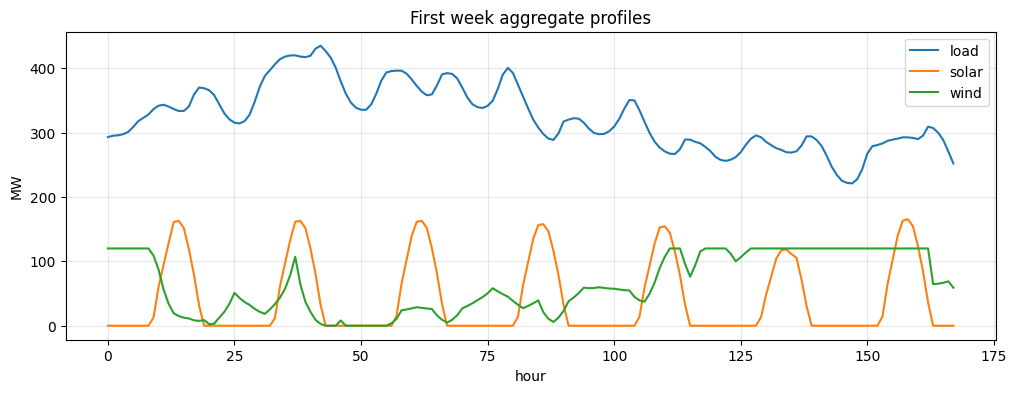

In [14]:
import matplotlib.pyplot as plt

T_plot = 24 * 7
load_total = data.get_series("load")[:T_plot].sum(axis=1)
solar_total = data.get_series("solar")[:T_plot].sum(axis=1)
wind_total = data.get_series("wind")[:T_plot].sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(load_total, label="load")
ax.plot(solar_total, label="solar")
ax.plot(wind_total, label="wind")
ax.set_title("First week aggregate profiles")
ax.set_xlabel("hour")
ax.set_ylabel("MW")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 10. Inspect One Bus CSV

A generated bus file can contain more than `load`, `solar`, and `wind`. Use `Data.get_bus_frame(...)` when you want the full table for a bus.

In [15]:
bus_idx = data.bus_ids()[0]
print("bus_idx:", bus_idx)
data.get_bus_frame(bus_idx).head()

bus_idx: 2


,Weekday_sin,Weekday_cos,Hour_sin,Hour_cos,Temperature (k),Shortwave Radiation (w/m2),Longwave Radiation (w/m2),Zonal Wind Speed (m/s),Meridional Wind Speed (m/s),Wind Speed (m/s),load,solar,wind
0,0.781831,0.62349,0.000000,1.000000,277.919678,0.0,238.750092,-1.07336,-5.37328,5.479438,23.115372,0.0,0.0
1,0.781831,0.62349,0.258819,0.965926,277.128174,0.0,267.544159,-1.48880,-6.05104,6.231502,23.392203,0.0,0.0
2,0.781831,0.62349,0.500000,0.866025,276.395844,0.0,267.537994,-1.28952,-6.17792,6.311066,23.530618,0.0,0.0
3,0.781831,0.62349,0.707107,0.707107,275.657349,0.0,267.534149,-1.09256,-6.29864,6.392695,23.807449,0.0,0.0
4,0.781831,0.62349,0.866025,0.500000,274.922729,0.0,282.061920,-0.88944,-6.42552,6.486787,24.222695,0.0,0.0


## 11. Build The UC Model Skeleton

The full script solves and post-processes the UC example. In a notebook, it is often better to first build the model and inspect dimensions before choosing a solver.

In [16]:
import importlib.util

example_py = EXAMPLE_DIR / "14bus_example.py"
spec = importlib.util.spec_from_file_location("bus14_uc_example", example_py)
bus14_uc_example = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bus14_uc_example)

T = 24
ug_init = [1, 1]
pg_init = 0.5 * (grid.gen.pmin + grid.gen.pmax) / grid.baseMVA
on_init = [2, 2]
off_init = [1, 1]

model = bus14_uc_example.build_uc(grid, T, ug_init, pg_init, on_init, off_init)
print("variables:", list(model.vars))
print("parameters:", list(model.params))
print("objective terms:", len(model.obj_terms))

variables: ['ug', 'yg', 'zg', 'pg', 'ls', 'solarc', 'windc', 'pf']
parameters: ['load', 'solar', 'wind']
objective terms: 168


## Optional: Compile Or Solve

The full unit-commitment problem is mixed-integer. Uncomment and adapt the cell below only if you have a suitable solver installed.

In [19]:
# parameters = {
#     "load": data.get_series("load")[:T, :] / grid.baseMVA,
#     "solar": data.get_series("solar")[:T, :] / grid.baseMVA,
#     "wind": data.get_series("wind")[:T, :] / grid.baseMVA,
# }
# problem = model.compile(**parameters)
# problem.solve(solver="MOSEK")
# print(problem.status, problem.value)